In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# --- 1. Hyperparameters ---
# Environment
T = 20  # Timesteps per trajectory
N_TRAIN_TRAJECTORIES = 200 # Number of trajectories for training data
NOISE_LEVEL = 0.1
NUM_DECOYS = 9 

# Plans
PLANS = {
    'A': {'id': 0, 'effect': 0.1},
    'B': {'id': 1, 'effect': 0.2}
}
# Ground truth: Plan B is better because its effect (0.2) is > Plan A's (0.1)

# Model
STATE_SIZE = 1 + NUM_DECOYS # 1 critical + N decoys
HIDDEN_UNITS = 32 # Enforce limited capacity
INPUT_SIZE = STATE_SIZE + 1 # state + plan_id
OUTPUT_SIZE = STATE_SIZE

# Training
LEARNING_RATE = 0.005 
EPOCHS = 4000 
LAMBDA = 0.5 

In [15]:
class SyntheticSystem:
    """
    The true dynamics of our synthetic world with multiple decoys.
    State is [x_critical, x_decoy_1, x_decoy_2, ...].
    """
    def __init__(self, num_decoys, noise_level=0.1):
        self.num_decoys = num_decoys
        self.state_size = 1 + num_decoys
        self.noise_level = noise_level
        
        # Create unique dynamics for each decoy
        np.random.seed(42)
        self.decoy_amplitudes = np.random.uniform(8, 12, num_decoys)
        self.decoy_frequencies = np.random.uniform(0.5, 0.9, num_decoys)

    def step(self, state, plan_effect):
        """Calculates the next state based on the true dynamics."""
        x_c = state[0]
        x_d = state[1:]
        
        # Critical dynamics: simple, plan-dependent linear progression
        next_x_c = x_c + plan_effect
        
        # Decoy dynamics: each decoy has its own complex dynamics
        noise = np.random.randn(self.num_decoys) * self.noise_level
        next_x_d = self.decoy_amplitudes * np.sin(self.decoy_frequencies * x_d) + noise
        
        next_state = np.concatenate(([next_x_c], next_x_d))
        return next_state

    def generate_full_trajectory(self, plan, T):
        """Generates a complete trajectory for a given plan."""
        states = np.zeros((T + 1, self.state_size))
        current_state = np.zeros(self.state_size)
        states[0] = current_state
        
        for t in range(T):
            current_state = self.step(current_state, plan['effect'])
            states[t + 1] = current_state
        return states

In [16]:
# --- 3. Data Generation ---

def generate_data(system, num_trajectories, T):
    """Generates a dataset of one-step transitions."""
    all_states = []
    all_plans = []
    all_next_states = []
    
    for _ in range(num_trajectories):
        # Randomly choose a plan for this trajectory
        plan_name = np.random.choice(list(PLANS.keys()))
        plan = PLANS[plan_name]
        
        states = system.generate_full_trajectory(plan, T)
        
        # Store the one-step transitions
        all_states.extend(states[:-1])
        all_next_states.extend(states[1:])
        all_plans.extend([plan['id']] * T)
        
    # Convert to torch tensors
    s_tensor = torch.tensor(np.array(all_states), dtype=torch.float32)
    p_tensor = torch.tensor(all_plans, dtype=torch.float32).view(-1, 1)
    ns_tensor = torch.tensor(np.array(all_next_states), dtype=torch.float32)
    
    return s_tensor, p_tensor, ns_tensor

In [17]:
# --- 4. Digital Twin Model ---

class DigitalTwin(nn.Module):
    """A simple, capacity-limited MLP to model the system dynamics."""
    def __init__(self, input_size, hidden_size, output_size):
        super(DigitalTwin, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
            
    def forward(self, state, plan_id):
            # Handle both batch and single instance
            if state.dim() == 1:
                state = state.unsqueeze(0)
            
            plan_tensor = plan_id.view(-1, 1)
            # Ensure plan tensor is broadcastable to the batch size of state
            if plan_tensor.shape[0] != state.shape[0]:
                plan_tensor = plan_tensor.expand(state.shape[0], -1)

            model_input = torch.cat((state, plan_tensor), dim=1)
            return self.network(model_input)

    def simulate_trajectory(self, plan, T):
        """Simulates a full trajectory using the learned dynamics."""
        with torch.no_grad():
            state_size = self.network[-1].out_features
            states = torch.zeros((T + 1, state_size))
            current_state = torch.zeros(state_size, dtype=torch.float32)
            states[0] = current_state
            
            plan_id_tensor = torch.tensor([plan['id']], dtype=torch.float32)
            
            for t in range(T):
                next_state_pred = self.forward(current_state, plan_id_tensor).squeeze(0)
                states[t + 1] = next_state_pred
                current_state = next_state_pred
        return states


In [18]:
def train_vanilla(data):
    """Trains a DT using only the standard MSE loss."""
    s, p, ns = data
    model = DigitalTwin(INPUT_SIZE, HIDDEN_UNITS, OUTPUT_SIZE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()
    
    print("--- Training Vanilla DT (MSE Loss) ---")
    for epoch in range(EPOCHS):
        predictions = model(s, p)
        loss = loss_fn(predictions, ns)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, MSE Loss: {loss.item():.4f}")
            
    return model

def train_decision_targeted(data, T, lambda_weight):
    """Trains a DT using the combined MSE + Ranking Loss."""
    s, p, ns = data
    model = DigitalTwin(INPUT_SIZE, HIDDEN_UNITS, OUTPUT_SIZE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    mse_loss_fn = nn.MSELoss()
    
    print("\n--- Training Decision-Targeted DT (DT²) ---")
    for epoch in range(EPOCHS):
        # L_sim
        predictions = model(s, p)
        L_sim = mse_loss_fn(predictions, ns)
        
        # L_rank
        sim_traj_A = model.simulate_trajectory(PLANS['A'], T)
        sim_traj_B = model.simulate_trajectory(PLANS['B'], T)
        U_sim_A = sim_traj_A[-1, 0] # Utility is still just the first state element
        U_sim_B = sim_traj_B[-1, 0]
        L_rank = torch.log(1 + torch.exp(U_sim_A - U_sim_B))
        
        # Combine
        total_loss = (1 - lambda_weight) * L_sim + lambda_weight * L_rank
        
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 1000 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Total Loss: {total_loss.item():.4f} "
                  f"(L_sim: {L_sim.item():.4f}, L_rank: {L_rank.item():.4f})")
            
    return model

def evaluate_model(model_name, model, T):
    """Evaluates the model's decision-making."""
    print(f"\n--- Evaluating {model_name} ---")
    
    sim_traj_A = model.simulate_trajectory(PLANS['A'], T)
    sim_traj_B = model.simulate_trajectory(PLANS['B'], T)
    
    U_sim_A = sim_traj_A[-1, 0]
    U_sim_B = sim_traj_B[-1, 0]
    
    print(f"Predicted Utility for Plan A: {U_sim_A:.4f}")
    print(f"Predicted Utility for Plan B: {U_sim_B:.4f}")
    
    if U_sim_B > U_sim_A:
        print("✅ Correct Decision: Model recommends Plan B.")
    else:
        print("❌ Incorrect Decision: Model does NOT recommend Plan B.")
        
    return sim_traj_A.numpy(), sim_traj_B.numpy()


--- Training Vanilla DT (MSE Loss) ---
Epoch 1000/4000, MSE Loss: 25.1680
Epoch 2000/4000, MSE Loss: 23.3403
Epoch 3000/4000, MSE Loss: 21.9777
Epoch 4000/4000, MSE Loss: 21.7612

--- Training Decision-Targeted DT (DT²) ---
Epoch 1000/4000, Total Loss: 12.5156 (L_sim: 24.2082, L_rank: 0.8231)
Epoch 2000/4000, Total Loss: 10.6672 (L_sim: 21.3345, L_rank: 0.0000)
Epoch 3000/4000, Total Loss: inf (L_sim: 21.2646, L_rank: inf)
Epoch 4000/4000, Total Loss: inf (L_sim: 21.2555, L_rank: inf)

--- Evaluating Vanilla DT ---
Predicted Utility for Plan A: 7530.8379
Predicted Utility for Plan B: 2499555.2500
✅ Correct Decision: Model recommends Plan B.

--- Evaluating Decision-Targeted DT (DT²) ---
Predicted Utility for Plan A: 114197.4531
Predicted Utility for Plan B: 22068.5566
❌ Incorrect Decision: Model does NOT recommend Plan B.


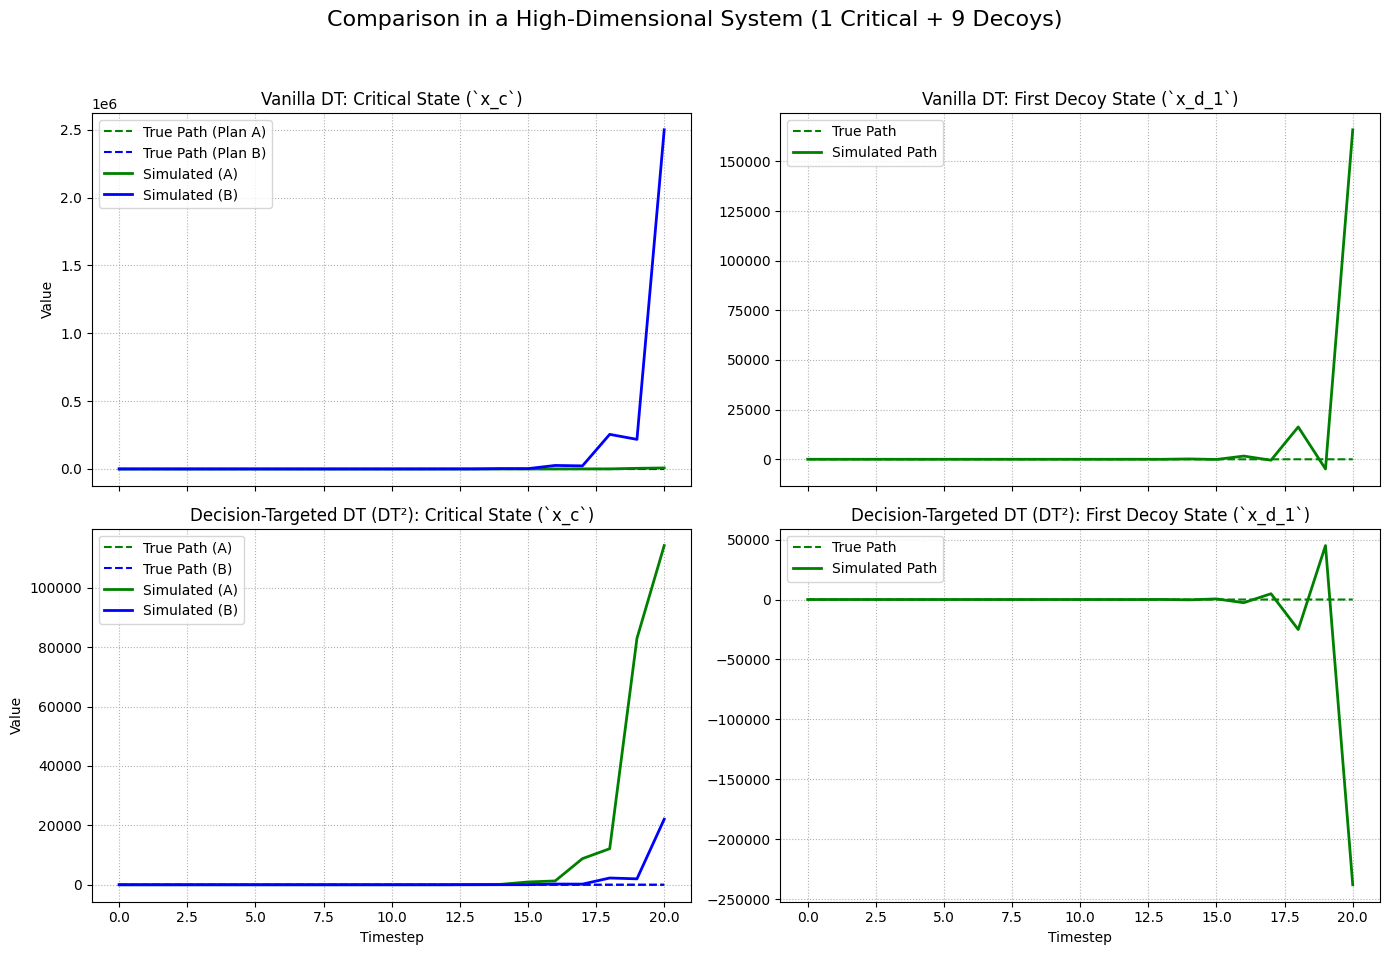

In [21]:
if __name__ == "__main__":
    # Setup
    env = SyntheticSystem(num_decoys=NUM_DECOYS, noise_level=NOISE_LEVEL)
    training_data = generate_data(env, N_TRAIN_TRAJECTORIES, T)

    # Train and evaluate
    vanilla_model = train_vanilla(training_data)
    dt2_model = train_decision_targeted(training_data, T, LAMBDA)
    
    vanilla_sim_A, vanilla_sim_B = evaluate_model("Vanilla DT", vanilla_model, T)
    dt2_sim_A, dt2_sim_B = evaluate_model("Decision-Targeted DT (DT²)", dt2_model, T)
    
    # Get ground truth for plotting
    true_A = env.generate_full_trajectory(PLANS['A'], T)
    true_B = env.generate_full_trajectory(PLANS['B'], T)

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    fig.suptitle(f'Comparison in a High-Dimensional System (1 Critical + {NUM_DECOYS} Decoys)', fontsize=16)
    timesteps = np.arange(T + 1)

    # Plot 1: Vanilla DT - Critical State
    axes[0, 0].set_title('Vanilla DT: Critical State (`x_c`)')
    axes[0, 0].plot(timesteps, true_A[:, 0], 'g--', label='True Path (Plan A)')
    axes[0, 0].plot(timesteps, true_B[:, 0], 'b--', label='True Path (Plan B)')
    axes[0, 0].plot(timesteps, vanilla_sim_A[:, 0], 'g-', lw=2, label='Simulated (A)')
    axes[0, 0].plot(timesteps, vanilla_sim_B[:, 0], 'b-', lw=2, label='Simulated (B)')
    axes[0, 0].set_ylabel('Value')
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle=':')

    # Plot 2: Vanilla DT - First Decoy State
    axes[0, 1].set_title('Vanilla DT: First Decoy State (`x_d_1`)')
    axes[0, 1].plot(timesteps, true_A[:, 1], 'g--', label='True Path')
    axes[0, 1].plot(timesteps, vanilla_sim_A[:, 1], 'g-', lw=2, label='Simulated Path')
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle=':')

    # Plot 3: DT² - Critical State
    axes[1, 0].set_title('Decision-Targeted DT (DT²): Critical State (`x_c`)')
    axes[1, 0].plot(timesteps, true_A[:, 0], 'g--', label='True Path (A)')
    axes[1, 0].plot(timesteps, true_B[:, 0], 'b--', label='True Path (B)')
    axes[1, 0].plot(timesteps, dt2_sim_A[:, 0], 'g-', lw=2, label='Simulated (A)')
    axes[1, 0].plot(timesteps, dt2_sim_B[:, 0], 'b-', lw=2, label='Simulated (B)')
    axes[1, 0].set_xlabel('Timestep')
    axes[1, 0].set_ylabel('Value')
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle=':')

    # Plot 4: DT² - First Decoy State
    axes[1, 1].set_title('Decision-Targeted DT (DT²): First Decoy State (`x_d_1`)')
    axes[1, 1].plot(timesteps, true_A[:, 1], 'g--', label='True Path')
    axes[1, 1].plot(timesteps, dt2_sim_A[:, 1], 'g-', lw=2, label='Simulated Path')
    axes[1, 1].set_xlabel('Timestep')
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle=':')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()